# **CNN**

El objetivo de este *notebook* es introducir el uso de capas *convolucionales* en redes neuronales para clasificación de imágenes.

Vamos a comparar el desempeño de una red densa con otra convolucional para clasificar imágenes de la base de datos [``EMNIST Letters``](https://www.nist.gov/itl/products-and-services/emnist-dataset).

Se trata de un *data set* de letras manuscritas, con 145.600 imágenes de 28x28 píxeles en escala de grises, distribuidas en 26 clases (una por cada letra del alfabeto inglés).

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
import torch.utils.data
import numpy as np

In [ ]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [ ]:
torch.manual_seed(100)
if torch.cuda.is_available():
    torch.cuda.manual_seed(100)

In [ ]:
train_transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize(0, 1)])

val_transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize(0, 1)])

In [ ]:
batch_size = 32

train_set = torchvision.datasets.EMNIST(root = './data', split = 'letters', train = True, download = True, transform = train_transform)
test_set = torchvision.datasets.EMNIST(root = './data', split = 'letters', train = False, download = True, transform = val_transform)
targets_ = train_set.targets

train_idx, val_idx = train_test_split(np.arange(len(targets_)), test_size = 0.2, stratify = targets_)
train_sampler = torch.utils.data.SubsetRandomSampler(train_idx)
val_sampler = torch.utils.data.SubsetRandomSampler(val_idx)

trainloader = torch.utils.data.DataLoader(train_set, sampler = train_sampler, batch_size = batch_size, num_workers = 2)
valloader = torch.utils.data.DataLoader(train_set, sampler = val_sampler, batch_size = batch_size, num_workers = 2)

testloader = torch.utils.data.DataLoader(test_set, batch_size = batch_size, shuffle = False, num_workers = 2)

100%|██████████| 562M/562M [00:03<00:00, 154MB/s]


In [ ]:
print('Train set size:', len(train_set))
print('Test set size:', len(test_set))

Train set size: 124800
Test set size: 20800


Veamos cómo son las imágenes.

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

In [ ]:
def imshow(img):
    img = img / 2 + 0.5 # Desnormalizamos.
    npimg = img.numpy()
    npimg = np.transpose(npimg, (1, 2, 0))
    npimg = np.rot90(npimg, 3)
    npimg = np.fliplr(npimg)
    plt.imshow(npimg)
    plt.show()

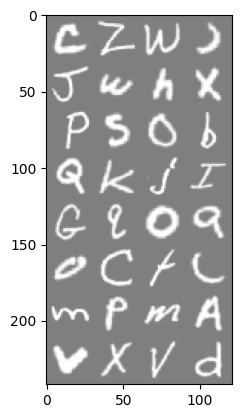

c     j     p     q     g     o     m     v     z     w     s     k     q     c     p     x     w     h     o     j     o     t     m     v     j     x     b     i     a     c     a     d    


In [ ]:
dataiter = iter(trainloader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images))
print(' '.join(f'{train_set.classes[labels[j]]:5s}' for j in range(batch_size)))

### **Clasificando con una red densa**

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
class DenseNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, 26)

    def forward(self, x):
        x = torch.flatten(x, 1)
        x = F.leaky_relu(self.fc1(x))
        x = F.leaky_relu(self.fc2(x))
        x = F.leaky_relu(self.fc3(x))
        x = self.fc4(x)
        return x

In [ ]:
net = DenseNet()
net.to(device)

DenseNet(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (fc4): Linear(in_features=128, out_features=26, bias=True)
)

Definimos la función de pérdida y el *optimizador*.

In [ ]:
import torch.optim as optim

In [ ]:
learning_rate = 0.01
momentum = 0.9

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr = learning_rate, momentum = momentum)

Entrenamos.

In [ ]:
epochs = 2

for epoch in range(epochs):

    running_loss = 0.0
    train_correct = 0
    total = 0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data[0].to(device), data[1].to(device) - 1
        # Restamos 1 para que las clases vayan de 0 a 25, en vez de 1 a 26.

        optimizer.zero_grad() # Reiniciamos los gradientes.

        outputs = net(inputs) # Hacemos la pasada forward.
        loss = criterion(outputs, labels) # Calculamos la pérdida.
        loss.backward() # Hacemos la pasada backward.
        optimizer.step() # Actualizamos los pesos.

        running_loss += loss.item() * inputs.shape[0]

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_accuracy = 100 * train_correct / total
    running_loss = running_loss / total

    # Veamos en validación.
    val_correct = 0
    total = 0
    val_loss = 0
    with torch.no_grad(): # Esta parte es sólo validación, no requiere entrenar, por lo que no calculamos gradientes.
        for data in valloader:
            images, labels = data[0].to(device), data[1].to(device) - 1
            outputs = net(images)
            _, predicted = torch.max(outputs.data, 1) # La ganadora es la que tiene mayor valor.
            total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            val_loss += criterion(outputs, labels).item() * images.shape[0]

    val_accuracy = 100 * val_correct / total
    val_loss = val_loss / total

    print(f'Epoch {epoch + 1 } finished. Train accuracy: {train_accuracy:.2f}%. Validation accuracy: {val_accuracy:.2f}%.')

print('Finished training.')

Epoch 1 finished. Train accuracy: 71.26%. Validation accuracy: 84.88%.
Epoch 2 finished. Train accuracy: 87.97%. Validation accuracy: 89.08%.
Finished training.


Ahora, veamos el *accuracy* en el conjunto de test.

Test accuracy: 89.18%.
Predicted:  a     a     a     q     a    
Ground truth:  a     a     a     a     a    


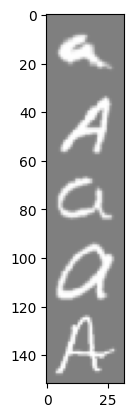

In [ ]:
# Calculamos el accuracy para todo el conjunto de test.
correct = 0
total = 0

first_predicted = None
first_labels = None
first_images = None

with torch.no_grad(): # No necesitamos calcular gradientes.
    for data in testloader:
        images, labels = data[0].to(device), data[1].to(device) - 1 # Recordar restar 1 a las etiquetas.
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        if first_predicted is None:
            first_predicted = predicted
            first_labels = labels
            first_images = images
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f'Test accuracy: {accuracy:.2f}%.')

print('Predicted: ', ' '.join(f'{test_set.classes[first_predicted[j] + 1]:5s}' for j in range(5)))
print('Ground truth: ', ' '.join(f'{test_set.classes[first_labels[j] + 1]:5s}' for j in range(5)))

# Lo vemos sólo para las primeras 5 imágenes.
imshow(torchvision.utils.make_grid(first_images[:5].cpu()))

### **Probemos ahora con capas convolucionales**

In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels = 1,   # 1 canal de entrada.
                               out_channels = 32, # 32 canales de salida.
                               kernel_size = 3,   # Kernel 3x3.
                               stride = 1,        # Pasos de 1.
                               padding = 1)       # Padding de 1 para mantener el tamaño.
        self.conv2 = nn.Conv2d(32, 64,
                               kernel_size = 3, stride = 1, padding = 1)
        self.fc1 = nn.Linear(64 * 7 * 7,
                             # 64 canales de 7x7 pues a la salida de cada capa
                             # convolucional se le aplica un maxpool de 2x2.
                             128)
        self.fc2 = nn.Linear(128, 26) # 26 clases para EMNIST letters.

    def forward(self, x):
        x = nn.LeakyReLU()(self.conv1(x))
        x = nn.MaxPool2d(kernel_size = 2, stride = 2)(x)
        x = nn.LeakyReLU()(self.conv2(x))
        x = nn.MaxPool2d(kernel_size = 2, stride = 2)(x)
        x = torch.flatten(x, 1)
        x = nn.LeakyReLU()(self.fc1(x))
        x = self.fc2(x)
        return x

In [ ]:
net = CNN()
net.to(device)

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=26, bias=True)
)

Definimos la función de pérdida y el optimizador.

In [ ]:
learning_rate = 0.01
momentum = 0.9

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr = learning_rate, momentum = momentum)

Entrenamos.

In [ ]:
epochs = 2

for epoch in range(epochs):

    running_loss = 0.0
    train_correct = 0
    total = 0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data[0].to(device), data[1].to(device) - 1

        optimizer.zero_grad()

        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.shape[0]

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_accuracy = 100 * train_correct / total
    running_loss = running_loss/total

    val_correct = 0
    total = 0
    val_loss = 0
    with torch.no_grad():
        for data in valloader:
            images, labels = data[0].to(device), data[1].to(device) - 1
            outputs = net(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            val_loss += criterion(outputs, labels).item() * images.shape[0]

    val_accuracy = 100 * val_correct / total
    val_loss = val_loss / total

    print(f'Epoch {epoch + 1} finished. Train accuracy: {train_accuracy:.2f}%. Validation accuracy: {val_accuracy:.2f}%.')

print('Finished training.')

Epoch 1 finished. Train accuracy: 82.47%. Validation accuracy: 90.29%.
Epoch 2 finished. Train accuracy: 91.84%. Validation accuracy: 91.98%.
Finished training.


Ahora, veamos el accuracy en el conjunto de test.

Test accuracy: 92.31%.
Predicted:  a     a     a     q     a    
Ground truth:  a     a     a     a     a    


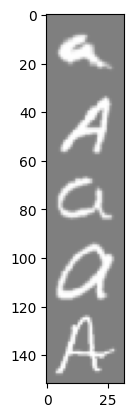

In [ ]:
correct = 0
total = 0

first_predicted = None
first_labels = None
first_images = None

with torch.no_grad():
    for data in testloader:
        images, labels = data[0].to(device), data[1].to(device) - 1
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        if first_predicted is None:
            first_predicted = predicted
            first_labels = labels
            first_images = images
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f'Test accuracy: {accuracy:.2f}%.')

print('Predicted: ', ' '.join(f'{test_set.classes[first_predicted[j] + 1]:5s}' for j in range(5)))
print('Ground truth: ', ' '.join(f'{test_set.classes[first_labels[j] + 1]:5s}' for j in range(5)))

imshow(torchvision.utils.make_grid(first_images[:5].cpu()))

## **Actividad: crear, entrenar, validar y testear una CNN propia**

En esta parte la idea es que cada uno o grupo si quieren trabajar de a más pueda proponer su propia arquitectura, verificar que las dimensiones de los *feature maps* cierren bien, entrenarla, validarla y finalmente medirla sobre el conjunto de *test*.

Para una capa convolucional 2D, el tamaño espacial de salida se calcula como:

$$
H_{out}=\left\lfloor \frac{H_{in}+2P-D(K-1)-1}{S}+1 \right\rfloor
$$

donde $K$ es el tamaño del *kernel*, $S$ el *stride*, $P$ el *padding* y $D$ la dilatación. Para las capas de este notebook vamos a usar \(D=1\).

Recordatorio: en EMNIST Letters las imágenes tienen forma $1 \times 28 \times 28$ y hay 26 clases.

Funciones de ayuda!

In [ ]:
def conv2d_out_size(size, kernel_size, stride = 1, padding = 0, dilation = 1):
    """Devuelve el tamaño espacial de salida de una Conv2d."""
    return (size + 2 * padding - dilation * (kernel_size - 1) - 1) // stride + 1


def maxpool2d_out_size(size, kernel_size = 2, stride = None, padding = 0, dilation = 1):
    """Devuelve el tamaño espacial de salida de un MaxPool2d."""
    if stride is None:
        stride = kernel_size
    return (size + 2 * padding - dilation * (kernel_size - 1) - 1) // stride + 1


def mostrar_shapes(model, input_shape = (1, 28, 28), device = device):
    """
    Muestra las dimensiones de salida de las capas principales.
    Sirve para revisar si el tamaño que pusimos en nn.Linear(...) es correcto.
    """
    model = model.to(device)
    model.eval()

    hooks = []

    def hook(module, inputs, output):
        if isinstance(output, torch.Tensor):
            print(f'{module.__class__.__name__:15s} -> {tuple(output.shape)}')

    for module in model.modules():
        if isinstance(module, (nn.Conv2d, nn.MaxPool2d, nn.Flatten, nn.Linear)):
            hooks.append(module.register_forward_hook(hook))

    x = torch.zeros(1, *input_shape).to(device)

    with torch.no_grad():
        y = model(x)

    for h in hooks:
        h.remove()

    print(f'Salida final      -> {tuple(y.shape)}')

In [ ]:
def entrenar_una_epoca(model, dataloader, criterion, optimizer, device = device, label_offset = 1):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device) - label_offset

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.shape[0]

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    avg_loss = running_loss / total
    accuracy = 100 * correct / total

    return avg_loss, accuracy


def evaluar(model, dataloader, criterion = None, device = device, label_offset = 1):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device) - label_offset

            outputs = model(images)

            if criterion is not None:
                running_loss += criterion(outputs, labels).item() * images.shape[0]

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_loss = running_loss / total if criterion is not None else None
    accuracy = 100 * correct / total

    return avg_loss, accuracy


def entrenar_modelo(model, trainloader = trainloader, valloader = valloader,
                    epochs = 2, learning_rate = 0.01, momentum = 0.9,
                    device = device):
    """
    Entrena cualquier modelo que reciba imágenes de forma [batch, 1, 28, 28]
    y devuelva 26 logits, uno por clase.
    """
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr = learning_rate, momentum = momentum)

    history = {
        'train_loss': [],
        'train_accuracy': [],
        'val_loss': [],
        'val_accuracy': []
    }

    for epoch in range(epochs):
        train_loss, train_accuracy = entrenar_una_epoca(model, trainloader, criterion, optimizer, device)
        val_loss, val_accuracy = evaluar(model, valloader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_accuracy'].append(train_accuracy)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_accuracy)

        print(
            f'Epoch {epoch + 1}/{epochs}. '
            f'Train loss: {train_loss:.4f}. Train accuracy: {train_accuracy:.2f}%. '
            f'Validation loss: {val_loss:.4f}. Validation accuracy: {val_accuracy:.2f}%.'
        )

    return history


def graficar_historial(history):
    epochs = range(1, len(history['train_accuracy']) + 1)

    plt.figure()
    plt.plot(epochs, history['train_accuracy'], marker = 'o', label = 'Train')
    plt.plot(epochs, history['val_accuracy'], marker = 'o', label = 'Validation')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title('Accuracy por epoch')
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(epochs, history['train_loss'], marker = 'o', label = 'Train')
    plt.plot(epochs, history['val_loss'], marker = 'o', label = 'Validation')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss por epoch')
    plt.legend()
    plt.show()


def testear_modelo(model, testloader = testloader, test_set = test_set,
                   device = device, mostrar_imagenes = 5):
    """
    Evalúa el modelo en test y muestra algunas predicciones.
    """
    criterion = nn.CrossEntropyLoss()
    test_loss, test_accuracy = evaluar(model, testloader, criterion, device)

    print(f'Test loss: {test_loss:.4f}.')
    print(f'Test accuracy: {test_accuracy:.2f}%.')

    first_images = None
    first_labels = None
    first_predicted = None

    model.eval()
    with torch.no_grad():
        for images, labels in testloader:
            images = images.to(device)
            labels = labels.to(device) - 1

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            first_images = images
            first_labels = labels
            first_predicted = predicted
            break

    n = min(mostrar_imagenes, first_images.shape[0])

    print('Predicted:    ', ' '.join(f'{test_set.classes[first_predicted[j].item() + 1]:5s}' for j in range(n)))
    print('Ground truth: ', ' '.join(f'{test_set.classes[first_labels[j].item() + 1]:5s}' for j in range(n)))

    imshow(torchvision.utils.make_grid(first_images[:n].cpu()))

### **Plantilla editable: mi propia CNN**

Esta plantilla ya funciona, pero está pensada para que ustedes la cambien:
- cantidad de canales,
- cantidad de capas,
- tamaño de los *kernels*,
- uso de *padding*,
- cantidad de neuronas de la capa densa.

Antes de entrenar, conviene llamar a `mostrar_shapes(modelo)` para revisar que las dimensiones cierren.

In [ ]:
class MiCNN(nn.Module):
    def __init__(self, c1 = 16, c2 = 32, hidden = 128):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels = 1,
                               out_channels = c1,
                               kernel_size = 3,
                               stride = 1,
                               padding = 1)

        self.pool1 = nn.MaxPool2d(kernel_size = 2, stride = 2)

        self.conv2 = nn.Conv2d(in_channels = c1,
                               out_channels = c2,
                               kernel_size = 3,
                               stride = 1,
                               padding = 1)

        self.pool2 = nn.MaxPool2d(kernel_size = 2, stride = 2)

        # Entrada: 1 x 28 x 28.
        # conv1 mantiene 28 x 28, pool1 pasa a 14 x 14.
        # conv2 mantiene 14 x 14, pool2 pasa a 7 x 7.
        # Por eso entran c2 * 7 * 7 features a la capa densa.
        self.fc1 = nn.Linear(c2 * 7 * 7, hidden)
        self.fc2 = nn.Linear(hidden, 26)

    def forward(self, x):
        x = F.leaky_relu(self.conv1(x))
        x = self.pool1(x)

        x = F.leaky_relu(self.conv2(x))
        x = self.pool2(x)

        x = torch.flatten(x, 1)

        x = F.leaky_relu(self.fc1(x))
        x = self.fc2(x)

        return x


mi_modelo = MiCNN(c1 = 16, c2 = 32, hidden = 128)
mostrar_shapes(mi_modelo)

# Cuando las dimensiones estén bien, se puede entrenar y testear así:
# historial = entrenar_modelo(mi_modelo, epochs = 2, learning_rate = 0.01)
# graficar_historial(historial)
# testear_modelo(mi_modelo)

Conv2d          -> (1, 16, 28, 28)
MaxPool2d       -> (1, 16, 14, 14)
Conv2d          -> (1, 32, 14, 14)
MaxPool2d       -> (1, 32, 7, 7)
Linear          -> (1, 128)
Linear          -> (1, 26)
Salida final      -> (1, 26)


## **Ejercicio 1: completar dimensiones**

Completar los `___` para que la arquitectura sea:

$$
1 \times 28 \times 28
\rightarrow \text{Conv}(16, K=3, S=1, P=1)
\rightarrow \text{MaxPool}(K=2, S=2)
\rightarrow \text{Conv}(32, K=3, S=1, P=1)
\rightarrow \text{MaxPool}(K=2, S=2)
\rightarrow \text{FC}(128)
\rightarrow \text{FC}(26)
$$

In [ ]:
class CNN_Ejercicio_1(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels = 1,
                               out_channels = ___,
                               kernel_size = 3,
                               stride = 1,
                               padding = 1)

        self.pool1 = nn.MaxPool2d(kernel_size = 2, stride = 2)

        self.conv2 = nn.Conv2d(in_channels = ___,
                               out_channels = ___,
                               kernel_size = 3,
                               stride = 1,
                               padding = 1)

        self.pool2 = nn.MaxPool2d(kernel_size = 2, stride = 2)

        self.fc1 = nn.Linear(___ * ___ * ___, 128)
        self.fc2 = nn.Linear(128, 26)

    def forward(self, x):
        x = F.leaky_relu(self.conv1(x))
        x = self.pool1(x)

        x = F.leaky_relu(self.conv2(x))
        x = self.pool2(x)

        x = torch.flatten(x, 1)

        x = F.leaky_relu(self.fc1(x))
        x = self.fc2(x)

        return x


# Después de completar:
# modelo_ej1 = CNN_Ejercicio_1()
# mostrar_shapes(modelo_ej1)
# historial = entrenar_modelo(modelo_ej1, epochs = 2)
# testear_modelo(modelo_ej1)

## **Ejercicio 2: completar dimensiones**

Completar los `___` para que la arquitectura sea:

$$
1 \times 28 \times 28
\rightarrow \text{Conv}(20, K=5, S=1, P=0)
\rightarrow \text{MaxPool}(K=2, S=2)
\rightarrow \text{Conv}(40, K=3, S=1, P=0)
\rightarrow \text{MaxPool}(K=2, S=2)
\rightarrow \text{FC}(100)
\rightarrow \text{FC}(26)
$$

Este ejercicio no usa *padding* en las convoluciones, por lo que los mapas de características se achican.

In [ ]:
class CNN_Ejercicio_2(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels = 1,
                               out_channels = ___,
                               kernel_size = 5,
                               stride = 1,
                               padding = 0)

        self.pool1 = nn.MaxPool2d(kernel_size = 2, stride = 2)

        self.conv2 = nn.Conv2d(in_channels = ___,
                               out_channels = ___,
                               kernel_size = 3,
                               stride = 1,
                               padding = 0)

        self.pool2 = nn.MaxPool2d(kernel_size = 2, stride = 2)

        self.fc1 = nn.Linear(___ * ___ * ___, 100)
        self.fc2 = nn.Linear(100, 26)

    def forward(self, x):
        x = F.leaky_relu(self.conv1(x))
        x = self.pool1(x)

        x = F.leaky_relu(self.conv2(x))
        x = self.pool2(x)

        x = torch.flatten(x, 1)

        x = F.leaky_relu(self.fc1(x))
        x = self.fc2(x)

        return x


# Después de completar:
# modelo_ej2 = CNN_Ejercicio_2()
# mostrar_shapes(modelo_ej2)
# historial = entrenar_modelo(modelo_ej2, epochs = 2)
# testear_modelo(modelo_ej2)

## **Ejercicio 3: completar dimensiones**

Completar los `___` para que la arquitectura sea:

$$
1 \times 28 \times 28
\rightarrow \text{Conv}(8, K=3, S=2, P=1)
\rightarrow \text{Conv}(16, K=3, S=1, P=1)
\rightarrow \text{MaxPool}(K=2, S=2)
\rightarrow \text{Conv}(32, K=3, S=1, P=0)
\rightarrow \text{FC}(64)
\rightarrow \text{FC}(26)
$$

Este ejercicio mezcla una convolución con `stride = 2`, una convolución que conserva tamaño y una convolución sin *padding*.

In [ ]:
class CNN_Ejercicio_3(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels = 1,
                               out_channels = ___,
                               kernel_size = 3,
                               stride = 2,
                               padding = 1)

        self.conv2 = nn.Conv2d(in_channels = ___,
                               out_channels = ___,
                               kernel_size = 3,
                               stride = 1,
                               padding = 1)

        self.pool1 = nn.MaxPool2d(kernel_size = 2, stride = 2)

        self.conv3 = nn.Conv2d(in_channels = ___,
                               out_channels = ___,
                               kernel_size = 3,
                               stride = 1,
                               padding = 0)

        self.fc1 = nn.Linear(___ * ___ * ___, 64)
        self.fc2 = nn.Linear(64, 26)

    def forward(self, x):
        x = F.leaky_relu(self.conv1(x))

        x = F.leaky_relu(self.conv2(x))
        x = self.pool1(x)

        x = F.leaky_relu(self.conv3(x))

        x = torch.flatten(x, 1)

        x = F.leaky_relu(self.fc1(x))
        x = self.fc2(x)

        return x


# Después de completar:
# modelo_ej3 = CNN_Ejercicio_3()
# mostrar_shapes(modelo_ej3)
# historial = entrenar_modelo(modelo_ej3, epochs = 2)
# testear_modelo(modelo_ej3)